In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
sys.path.append("../")

import os
import re
import six
import random
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter, FuncFormatter
import seaborn as sns
from scorecardpipeline import *


init_setting()

### 三方数据评估报告输出

In [2]:
# 参考: https://scorecardpipeline.itlubber.art/scorecardpipeline.html#module-scorecardpipeline.auto_report
# pip install scorecardpipeline -i https://pypi.org/simple

from scorecardpipeline import *

# 初始化设置，包含忽略warning、画图字体、[随机种子、日志输出]
init_setting()

# 加载数据集，标签转换为 0 和 1
target = "creditability"
data = germancredit()
data[target] = data[target].map({"good": 0, "bad": 1})
features = data.columns.drop(target).tolist()

# 测试报告输出
auto_data_testing_report(data
                         , features=features
                         , target=target
                         , date=None # 传入日期列名，会按 freq 统计不同时间维度好坏样本的分布情况
                         , freq="M"
                         , data_summary_comment=""
                         , excel_writer="model_report/三方数据测试报告.xlsx"
                         , sheet="分析报告"
                         , start_col=2
                         , start_row=2
                         , writer_params={}
                         , bin_params={"method": "dt", "min_bin_size": 0.05, "max_n_bins": 10} # feature_bin_stats 函数的相关参数
                         , pictures=['bin', 'ks', 'hist'] # 类别型变量不支持 ks 和 hist
                         , corr=True
                         )

100%|███████████████████████████████████| 20/20 [00:09<00:00,  2.10it/s, feature=installment_rate_in_percentage_of_disposable_income]


(742, 24)

In [3]:
from scorecardpipeline import *

# 初始化设置，包含忽略warning、画图字体、[随机种子、日志输出]
init_setting()

# 加载数据集，标签转换为 0 和 1
target = "creditability"
data = germancredit()
data[target] = data[target].map({"good": 0, "bad": 1})
features = data.columns.drop(target).tolist()

swapout_report(data, rules=[Rule('credit_amount < 2000'), Rule('age_in_years < 25')], target=target, overdue=[target], dpd=[0])

规则详情              creditability DPD0+                                                                             
                     分箱  样本总数   样本占比                好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善   风险拒绝比    准确率    精确率    召回率   F1分数
0                  原始样本  1000 1.0000                 700 1.0000  300 1.0000 0.3000 1.0000  0.0000  0.0000    NaN    NaN    NaN    NaN
1  credit_amount < 2000   432 0.4320                 311 0.4443  121 0.4033 0.2801 0.9336 -0.0505 -0.1168 0.5100 0.2801 0.4033 0.3306
2                  剩余样本   568 0.5680                 389 0.5557  179 0.5967 0.3151 1.0505  0.0664  0.1168 0.4900 0.3151 0.5967 0.4124
3     age_in_years < 25    75 0.1320                  43 0.1105   32 0.1788 0.4267 1.3539  0.0538  0.4077 0.6655 0.4267 0.1788 0.2520
4                  剩余样本   493 0.8680                 346 0.8895  147 0.8212 0.2982 0.9462 -0.3539 -0.4077 0.3345 0.2982 0.8212 0.4375
5                    汇总   507 0.5070                 354 0.5057  153 0.5100 0.3018 1.0059  0.0061  0.0120 0.4990 0.3018 0.5100 0.3792

In [4]:
swap_in_data, swap_in_data_amount = sawpin_badrate_prediction_by_score(
    data, data.sample(n=500), [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')], "credit_amount", 
    target=target, amount="credit_amount"
)

swap_in_data

,样本总数,样本占比,坏样本数,坏样本率,LIFT值,坏账改善,风险拒绝比
规则详情,,,,,,,
原始样本,125.0000,0.2500,35.0962,0.2808,0.9258,0.0742,0.2969
((credit_amount > 2000) & (age_in_years > 25)) | (duration_in_month > 12),375.0000,0.7500,116.5457,0.3108,1.0247,-0.0247,-0.0330
置换样本,500.0000,1.0000,151.6419,0.3033,1.0000,0.0000,0.0000


In [5]:
swap_in_data, swap_in_data_amount = sawpin_badrate_prediction_by_score(
    data, data.sample(n=500), [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')], "credit_amount", 
    overdue=target, dpd=[0, 1], amount="credit_amount"
)

swap_in_data

规则详情        creditability 0+                               creditability 1+                        
                                                                              样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比             坏样本数   坏样本率 LIFT值 坏账改善 风险拒绝比
规则详情                                                                                                                                                                             
原始样本                                                                      135.0000 0.2700          38.0062 0.2815 0.9459  0.0541  0.2004           0.0000 0.0000   NaN  NaN   NaN
((credit_amount > 2000) & (age_in_years > 25)) | (duration_in_month > 12) 365.0000 0.7300         110.8110 0.3036 1.0200 -0.0200 -0.0274           0.0000 0.0000   NaN  NaN   NaN
置换样本                                                                      500.0000 1.0000         148.8172 0.2976 1.0000  0.0000  0.0000           0.0000 0.0000   NaN  NaN   NaN

In [6]:
swap_in_ruleset = [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')]

swap_in_data = data.sample(n=500)

report, report_amount = swapin_report(
    test=swap_in_data,
    feature="credit_amount",
    target=target,
    base=data,
    swap_in_ruleset=swap_in_ruleset,
    amount="credit_amount",
)

display(report)

report, report_amount = swapin_report(
    test=swap_in_data,
    feature="credit_amount",
    overdue=[target],
    dpd=[0],
    base=data,
    swap_in_ruleset=swap_in_ruleset,
    amount="credit_amount",
)

display(report_amount)

,样本总数,样本占比,坏样本数,坏样本率,LIFT值,坏账改善,风险拒绝比
规则详情,,,,,,,
原始样本,133.0000,1.0000,37.5670,0.2825,1.0000,0.0000,0.0000
(credit_amount > 2000) & (age_in_years > 25),230.0000,1.7293,73.8658,0.3212,1.1370,-0.0868,-0.0502
置换样本,363.0000,2.7293,111.4327,0.3070,1.0868,-0.0635,-0.0233
duration_in_month > 12,137.0000,1.0301,38.4298,0.2805,0.9931,0.0035,0.0034
通过样本,500.0000,3.7594,149.8626,0.2997,1.0611,-0.0483,-0.0128


规则详情        creditability 0+                              
                                                     样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                           
原始样本                                          172527.0000 1.0000       49758.5100 0.2884 1.0000  0.0000  0.0000
(credit_amount > 2000) & (age_in_years > 25) 1130459.0000 6.5524      414077.1265 0.3663 1.2700 -0.2343 -0.0358
置换样本                                         1302986.0000 7.5524      463835.6366 0.3560 1.2343 -0.2069 -0.0274
duration_in_month > 12                        348251.0000 2.0185      111472.6755 0.3201 1.1099 -0.0735 -0.0364
通过样本                                         1651237.0000 9.5709      575308.3121 0.3484 1.2080 -0.1884 -0.0197

In [7]:
swap_in_ruleset = [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')]

report = pd.DataFrame()

swap_in_data_temp = data.sample(n=500)

report, report_amount = swapin_report(
    test=swap_in_data_temp,
    feature="credit_amount",
    overdue=[target],
    dpd=[0],
    base=data,
    swap_in_ruleset=swap_in_ruleset,
    amount="credit_amount",
)

report

规则详情        creditability 0+                              
                                                 样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                       
原始样本                                         133.0000 1.0000          37.6387 0.2830 1.0000  0.0000  0.0000
(credit_amount > 2000) & (age_in_years > 25) 239.0000 1.7970          75.3333 0.3152 1.1138 -0.0731 -0.0407
置换样本                                         372.0000 2.7970         112.9721 0.3037 1.0731 -0.0539 -0.0193
duration_in_month > 12                       128.0000 0.9624          36.3431 0.2839 1.0033 -0.0016 -0.0017
通过样本                                         500.0000 3.7594         149.3151 0.2986 1.0552 -0.0436 -0.0116

In [8]:
# swap_in_ruleset = [Rule('duration_in_month > 12'), Rule('credit_amount > 2000') & Rule('age_in_years > 25')]
swap_in_ruleset = [Rule('credit_amount > 2000') & Rule('age_in_years > 25'), Rule('duration_in_month > 12')]

report = pd.DataFrame()

swap_in_data_temp = data.sample(n=500)

report, report_amount = swapin_report(
    test=swap_in_data_temp,
    feature="credit_amount",
    overdue=[target],
    dpd=[0],
    base=data,
    swap_in_ruleset=swap_in_ruleset,
    amount="credit_amount",
)

report

规则详情        creditability 0+                              
                                                 样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                       
原始样本                                         132.0000 1.0000          37.0651 0.2808 1.0000  0.0000  0.0000
(credit_amount > 2000) & (age_in_years > 25) 237.0000 1.7955          75.7543 0.3196 1.1383 -0.0888 -0.0495
置换样本                                         369.0000 2.7955         112.8195 0.3057 1.0888 -0.0654 -0.0234
duration_in_month > 12                       131.0000 0.9924          37.2523 0.2844 1.0127 -0.0063 -0.0064
通过样本                                         500.0000 3.7879         150.0718 0.3001 1.0689 -0.0545 -0.0144

In [9]:
swap_in_ruleset = [Rule('duration_in_month > 12'), Rule('credit_amount > 2000') & Rule('age_in_years > 25')]

report = pd.DataFrame()

# swap_in_data_temp = data.sample(n=500)

report, report_amount = swapin_report(
    test=swap_in_data_temp,
    feature="credit_amount",
    overdue=[target],
    dpd=[0],
    base=data,
    swap_in_ruleset=swap_in_ruleset,
    amount="credit_amount",
)

report

规则详情        creditability 0+                              
                                                 样本总数   样本占比             坏样本数   坏样本率  LIFT值    坏账改善   风险拒绝比
规则详情                                                                                                       
原始样本                                         132.0000 1.0000          37.0651 0.2808 1.0000  0.0000  0.0000
duration_in_month > 12                       328.0000 2.4848         101.8260 0.3104 1.1056 -0.0753 -0.0303
置换样本                                         460.0000 3.4848         138.8911 0.3019 1.0753 -0.0585 -0.0168
(credit_amount > 2000) & (age_in_years > 25)  40.0000 0.3030          11.1807 0.2795 0.9954  0.0011  0.0035
通过样本                                         500.0000 3.7879         150.0718 0.3001 1.0689 -0.0545 -0.0144

In [10]:
# 直接分析 test 数据集的分箱统计（无需  swap_in_ruleset）
report, report_amount = swapin_report(
    test=swap_in_data_temp,
    feature="credit_amount",
    base=data,
    overdue=[target],
    dpd=[0],
    amount="credit_amount",
)

display(report)

规则详情        creditability 0+                            
             样本总数   样本占比             坏样本数   坏样本率  LIFT值   坏账改善  风险拒绝比
规则详情                                                                 
原始样本 1647628.0000 1.0000      573025.1972 0.3478 1.0000 0.0000 0.0000

### 直接使用 swapin_report 分析 test 数据（无需 base 和 swap_in_ruleset）

新接口支持直接分析 test 数据集的分箱统计，无需传入 base 和 swap_in_ruleset：

### 自动EDA输出报告

### 自动EDA输出报告

In [11]:
# https://scorecardpipeline.itlubber.art/scorecardpipeline.html#module-scorecardpipeline.auto_eda
from scorecardpipeline import *

# 加载数据集
data = germancredit()

# 设置目标变量名称 & 映射目标变量值域为 {0, 1}
target = "creditability"
data[target] = data[target].map({"good": 0, "bad": 1})

# 自动 eda 并保存文件
auto_eda_sweetviz(data, target=target, save="model_report/auto_eda.html")

Done! Use 'show' commands to display/save.   |███████████████████████████████████████████████████████| [100%]   00:01 -> (00:00 left)

Report model_report/auto_eda.html was generated.


In [12]:
init_setting()

分箱详情                                                        creditability 0+                              
            指标名称               指标含义                  分箱     样本总数   样本占比             坏样本数   坏样本率  LIFT值 累积LIFT值   分档KS值
0  credit_amount  样本数 1000 坏样本率 0.3       [负无穷 , 605.0)  24.0000 0.0240           3.0000 0.1250 0.4167  1.0143 -0.0200
1  credit_amount  样本数 1000 坏样本率 0.3    [605.0 , 3913.5) 716.0000 0.7160         186.0000 0.2598 0.8659  1.4231 -0.1571
2  credit_amount  样本数 1000 坏样本率 0.3   [3913.5 , 6193.0) 117.0000 0.1170          44.0000 0.3761 1.2536  1.5618 -0.1148
3  credit_amount  样本数 1000 坏样本率 0.3  [6193.0 , 10918.0) 112.0000 0.1120          45.0000 0.4018 1.3393  2.3656 -0.0605
4  credit_amount  样本数 1000 坏样本率 0.3     [10918.0 , 正无穷)  31.0000 0.0310          22.0000 0.7097 2.3656  0.0000  0.0000
5  credit_amount  样本数 1000 坏样本率 0.3                 缺失值   0.0000 0.0000           0.0000 0.0000 0.0000  0.0000  0.0000

分箱详情                                            creditability 0+                              
             指标名称 指标含义                    分箱     样本总数   样本占比             坏样本数   坏样本率  LIFT值 累积LIFT值   分档KS值
0   credit_amount             [负无穷 , 425.83)  10.0000 0.0100           0.0000 0.0000 0.0000  1.0101 -0.0143
1   credit_amount          [425.83 , 570.02)  10.0000 0.0100           3.0000 0.3000 1.0000  1.0102 -0.0143
2   credit_amount           [570.02 , 638.7)  10.0000 0.0100           2.0000 0.2000 0.6667  1.0137 -0.0190
3   credit_amount           [638.7 , 708.95)  20.0000 0.0200           7.0000 0.3500 1.1667  1.0105 -0.0143
4   credit_amount           [708.95 , 932.0)  49.0000 0.0490          19.0000 0.3878 1.2925  0.9952  0.0062
5   credit_amount           [932.0 , 1262.0)  99.0000 0.0990          30.0000 0.3030 1.0101  0.9933  0.0076
6   credit_amount          [1262.0 , 1906.8) 202.0000 0.2020          48.0000 0.2376 0.7921  1.0611 -0.0524
7   credit_amount       [1906.8 , 2852.3999) 200.0000 0.2000          54.0000 0.2700 0.9000  1.1417 -0.0810
8   credit_amount       [2852.3999 , 4720.0) 200.0000 0.2000          52.0000 0.2600 0.8667  1.4167 -0.1190
9   credit_amount             [4720.0 , 正无穷) 200.0000 0.2000          85.0000 0.4250 1.4167  0.0000  0.0000
10  credit_amount                        缺失值   0.0000 0.0000           0.0000 0.0000 0.0000  0.0000  0.0000

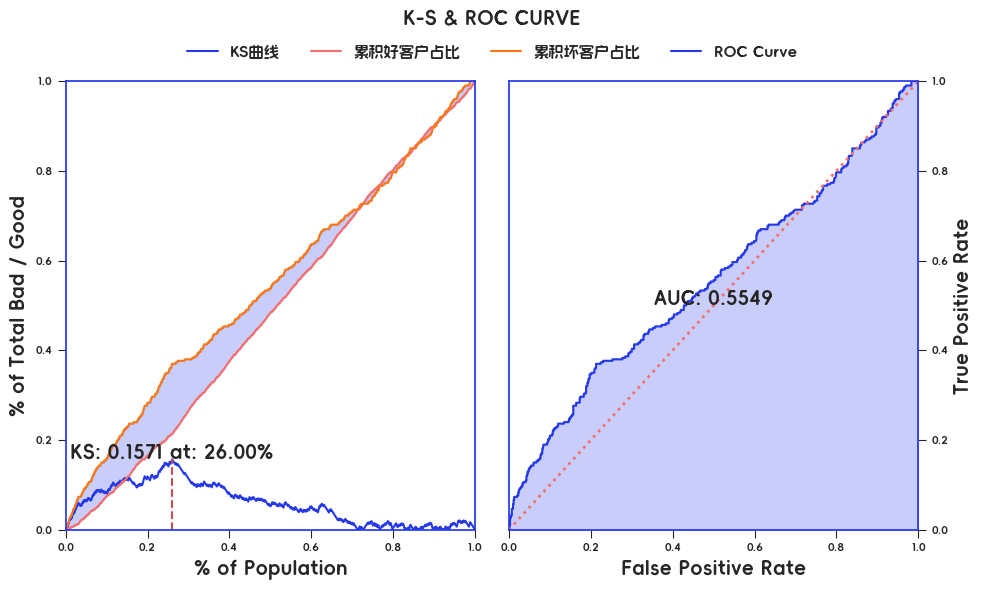

In [13]:
feature_efficiency_analysis(data, 'credit_amount', overdue=[target], dpd=[0], ks=True)

### 特征区分度

In [14]:
from scorecardpipeline import *

# 初始化配置
init_setting()

# 加载数据集
data = germancredit()

# 设置目标变量名称 & 映射目标变量值域为 {0, 1}
target = "creditability"
data[target] = data[target].map({"good": 0, "bad": 1})

use_cols = ['指标名称', '指标含义', '分箱', '样本总数', '样本占比', '好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', '分档WOE值', '指标IV值', 'LIFT值', '坏账改善', '累积LIFT值', '累积坏账改善', '分档KS值']

# 使用 MDLP 自动分箱查看特征区分度
table_mdlp = feature_bin_stats(data, "duration_in_month", target=target, method="mdlp", desc="在账月份", max_n_bins=5)[use_cols]
bin_plot(table_mdlp, desc="在账月份 MDLP ", save="model_report/duration_in_month_mdlp_binplot.png")

# 使用 step 验证特征泛化能力
table_step = feature_bin_stats(data, "duration_in_month", target=target, method="step", desc="在账月份", max_n_bins=5)[use_cols]
bin_plot(table_step, desc="在账月份 STEP ", save="model_report/duration_in_month_step_binplot.png")

# 初始化 Excel 写入器
writer = ExcelWriter()

end_row, end_col = dataframe2excel(table_mdlp,
                                   writer,
                                   sheet_name="分箱信息",
                                   percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "累积LIFT值", "坏账改善", "累积坏账改善"],
                                   condition_cols=["坏样本率", "LIFT值"],
                                   start_row=2,
                                   merge_column=["指标名称", "指标含义", "指标IV值"],
                                   merge=True,
                                   title="duration_in_month（在账月份） MDLP 特征区分度",
                                   figures=[f"model_report/duration_in_month_mdlp_binplot.png"])

end_row, end_col = dataframe2excel(table_step,
                                   writer,
                                   sheet_name="分箱信息",
                                   percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "累积LIFT值", "坏账改善", "累积坏账改善"],
                                   condition_cols=["坏样本率", "LIFT值"],
                                   start_row=end_row + 2,
                                   merge_column=["指标名称", "指标含义", "指标IV值"],
                                   merge=True,
                                   title="duration_in_month（在账月份） STEP 特征区分度",
                                   figures=[f"model_report/duration_in_month_step_binplot.png"])

# 保存到 excel 文件
writer.save("model_report/数据有效性之特征区分度.xlsx")

In [15]:
# 随机生成逾期天数，模拟客户逾期数据
data["MOB1"] = np.where(np.random.random(len(data)) <= 0.8, 0, np.random.randint(1, 31, size=len(data)))

table = feature_bin_stats(data, "duration_in_month", overdue=["MOB1"], dpd=[0, 3], method="mdlp", max_n_bins=5, empty_separate=True, return_rules=False, del_grey=True, return_cols=['样本总数', '样本占比', '好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', 'LIFT值', '累积LIFT值', '坏账改善', '累积坏账改善', '分档KS值'])

percent_cols = ["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "坏账改善", "累积LIFT值", "累积坏账改善"]
condition_cols = ["坏样本率", "LIFT值"]

dataframe2excel(table
                , "model_report/数据有效性之特征区分度.xlsx"
                , percent_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in percent_cols) or (not isinstance(c, tuple) and c in percent_cols)]
                , condition_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in condition_cols) or (not isinstance(c, tuple) and c in condition_cols)]
                )

table

分箱详情                     MOB1 0+                                                ...  MOB1 3+                                                                   
                指标名称 指标含义            分箱     样本总数   样本占比     好样本数  好样本占比     坏样本数  坏样本占比   坏样本率  ...     好样本数  好样本占比     坏样本数  坏样本占比   坏样本率  LIFT值    坏账改善 累积LIFT值 累积坏账改善  分档KS值
0  duration_in_month       [负无穷 , 11.5) 180.0000 0.1800 149.0000 0.1849  31.0000 0.1598 0.1722  ... 149.0000 0.1849  27.0000 0.1588 0.1534 0.8807 -0.0262  0.0000 0.0000 0.0000
1  duration_in_month       [11.5 , 正无穷) 820.0000 0.8200 657.0000 0.8151 163.0000 0.8402 0.1988  ... 657.0000 0.8151 143.0000 0.8412 0.1787 1.0262  0.1193  0.8807 0.1193 0.0260
2  duration_in_month                缺失值   0.0000 0.0000   0.0000 0.0000   0.0000 0.0000 0.0000  ...   0.0000 0.0000   0.0000 0.0000 0.0000 0.0000  0.0000  0.0000 0.0000 0.0000

[3 rows x 27 columns]

### 模型增益效果评估

In [16]:
# 选择需要评估的特征集
feature = ["duration_in_month"]

def calculate_model_score(data, target="target"):
    # 构建 pipeline
    model_pipeline = Pipeline([
        ("preprocessing", FeatureSelection(target=target, engine="toad")),
        ("combiner", Combiner(target=target, min_bin_size=0.1, max_n_bins=5, method="mdlp")),
        ("transform", WOETransformer(target=target)),
        ("processing_select", FeatureSelection(target=target, engine="toad")),
        ("stepwise", StepwiseSelection(target=target)),
        ("logistic", ITLubberLogisticRegression(target=target)),
    ])

    # 训练 pipeline
    model_pipeline.fit(data)

    # 计算模型指标
    return KS(model_pipeline.predict_proba(data)[:, -1], data[target])

# 计算模型指标增益效果
improvement = calculate_model_score(data, target=target) - calculate_model_score(data.drop(columns=feature), target=target)

print(f"特征: duration_in_month 在账月份 KS 增益效果 {improvement * 100:.4f}%")

特征: duration_in_month 在账月份 KS 增益效果 0.3333%


### 规则增益效果评估

In [17]:
from scorecardpipeline import *

# 初始化配置
init_setting()

# 加载数据集
data = germancredit()

# 设置目标变量名称 & 映射目标变量值域为 {0, 1}
target = "creditability"
data[target] = data[target].map({"good": 0, "bad": 1})

# 随机生成逾期天数，模拟客户逾期数据
data["MOB1"] = np.where(np.random.random(len(data)) <= 0.8, 0, np.random.randint(1, 31, size=len(data)))

In [18]:
rule = Rule("duration_in_month > 43.5")
rule.report(data[["duration_in_month", target]], target=target)

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,验证规则,duration_in_month > 43.5,命中,70,0.0700,30,0.0429,40,0.1333,0.5714,1.9048,0.0681,0.9729,0.7100,0.5714,0.1333,0.2162
1,验证规则,duration_in_month > 43.5,未命中,930,0.9300,670,0.9571,260,0.8667,0.2796,0.9319,-0.9048,-0.9729,0.2900,0.2796,0.8667,0.4228


In [19]:
rule = Rule("duration_in_month > 43.5")
rule.report(data[["duration_in_month", "MOB1"]], overdue=["MOB1"], dpd=[0, 3, 7, 15], filter_cols=['坏样本率', 'LIFT值', '坏账改善', '样本占比'], del_grey=False)

规则详情                                            MOB1 DPD0+                MOB1 DPD3+                MOB1 DPD7+                MOB1 DPD15+               
   规则分类                      指标名称   分箱 样本总数   样本占比       坏样本率  LIFT值    坏账改善       坏样本率  LIFT值    坏账改善       坏样本率  LIFT值    坏账改善        坏样本率  LIFT值    坏账改善
0  验证规则  duration_in_month > 43.5   命中   70 0.0700     0.2857 1.4728  0.0356     0.1857 1.0673  0.0051     0.1286 0.8867 -0.0085      0.0429 0.4161 -0.0440
1  验证规则  duration_in_month > 43.5  未命中  930 0.9300     0.1871 0.9644 -0.4728     0.1731 0.9949 -0.0673     0.1462 1.0085  0.1133      0.1075 1.0440  0.5839

In [20]:
prior_rules = Rule("credit_amount > 3972.25")
rule.report(data[["duration_in_month", "credit_amount", target]], target=target, prior_rules=prior_rules)

,规则分类,指标名称,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT值,坏账改善,风险拒绝比,准确率,精确率,召回率,F1分数
0,先验规则,credit_amount > 3972.25,命中,250,0.2500,145,0.2071,105,0.3500,0.4200,1.4000,0.1333,0.5333,0.6600,0.4200,0.3500,0.3818
1,先验规则,credit_amount > 3972.25,未命中,750,0.7500,555,0.7929,195,0.6500,0.2600,0.8667,-0.4000,-0.5333,0.3400,0.2600,0.6500,0.3714
0,验证规则,duration_in_month > 43.5,命中,11,0.0147,4,0.0072,7,0.0359,0.6364,2.4476,0.0215,1.4691,0.7440,0.6364,0.0359,0.0680
1,验证规则,duration_in_month > 43.5,未命中,739,0.9853,551,0.9928,188,0.9641,0.2544,0.9785,-1.4476,-1.4691,0.2560,0.2544,0.9641,0.4026


In [21]:
pd.set_option('display.max_columns', None)

In [22]:
prior_rules = Rule("credit_amount > 3972.25")
rule = Rule("duration_in_month > 43.5")

rule.report(data[["duration_in_month", "credit_amount", "MOB1"]], overdue=["MOB1"], dpd=[0, 3, 7, 15], prior_rules=prior_rules, filter_cols=['坏样本数', '坏样本率', 'LIFT值', '坏账改善', '样本占比'], del_grey=True)

规则详情                                MOB1 DPD0+                            MOB1 DPD3+                            MOB1 DPD7+                            MOB1 DPD15+                           
   规则分类                      指标名称   分箱       样本占比 坏样本数   坏样本率  LIFT值    坏账改善       样本占比 坏样本数   坏样本率  LIFT值    坏账改善       样本占比 坏样本数   坏样本率  LIFT值    坏账改善        样本占比 坏样本数   坏样本率  LIFT值    坏账改善
0  先验规则   credit_amount > 3972.25   命中     0.2500   48 0.1920 0.9897 -0.0034     0.2480   41 0.1687 0.9503 -0.0164     0.2461   32 0.1368 0.8969 -0.0336      0.2420   18 0.0818 0.7221 -0.0887
1  先验规则   credit_amount > 3972.25  未命中     0.7500  146 0.1947 1.0034  0.0103     0.7520  133 0.1805 1.0164  0.0497     0.7539  113 0.1576 1.0336  0.1031      0.7580   85 0.1234 1.0887  0.2779
2  验证规则  duration_in_month > 43.5   命中     0.0147    3 0.2727 1.4010  0.0060     0.0122    1 0.1111 0.6157 -0.0048     0.0126    1 0.1111 0.7050 -0.0037      0.0131    1 0.1111 0.9007 -0.0013
3  验证规则  duration_in_month > 43.5  未命中     0.9853  143 0.1935 0.9940 -0.4010     0.9878  132 0.1813 1.0048  0.3843     0.9874  112 0.1582 1.0037  0.2950      0.9869   84 0.1235 1.0013  0.0993

In [23]:
# all_data = load_pickle("/Users/lubberit/Desktop/workspace/scorecardpipeline/examples/all_data_qhyp.pkl")
# rule = Rule("(X1 < 588.5) & (X2 < 509.5)")
# prior_rule = Rule("放款金额 < 5000")
# all_data["target"] = (all_data["MOB1"] > 0).astype(int)
# table = rule.report(all_data[["X1", "X2", "放款金额", "MOB1", "target"]]
#                     , overdue=["MOB1"]
#                     , dpd=[0, 1, 2, 3, 4]
#                     , prior_rules=prior_rule
#                     # , filter_cols=['好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', 'LIFT值', '坏账改善']
#                     )
# print(table)

# percent_cols = ["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "坏账改善", "累积LIFT值", "累积坏账改善"]
# condition_cols = ["坏样本率", "LIFT值"]
# dataframe2excel(table, "规则有效性验证.xlsx", percent_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in percent_cols) or (not isinstance(c, tuple) and c in percent_cols)]
#                 , condition_cols=[c for c in table.columns if (isinstance(c, tuple) and c[-1] in condition_cols) or (not isinstance(c, tuple) and c in condition_cols)]
#                 )


### 特征分箱风险趋势图

`bin_trend_plot` 用于绘制特征在不同维度下的样本分布、坏率走势和统计指标，支持按时间维度或指定维度列分组展示。

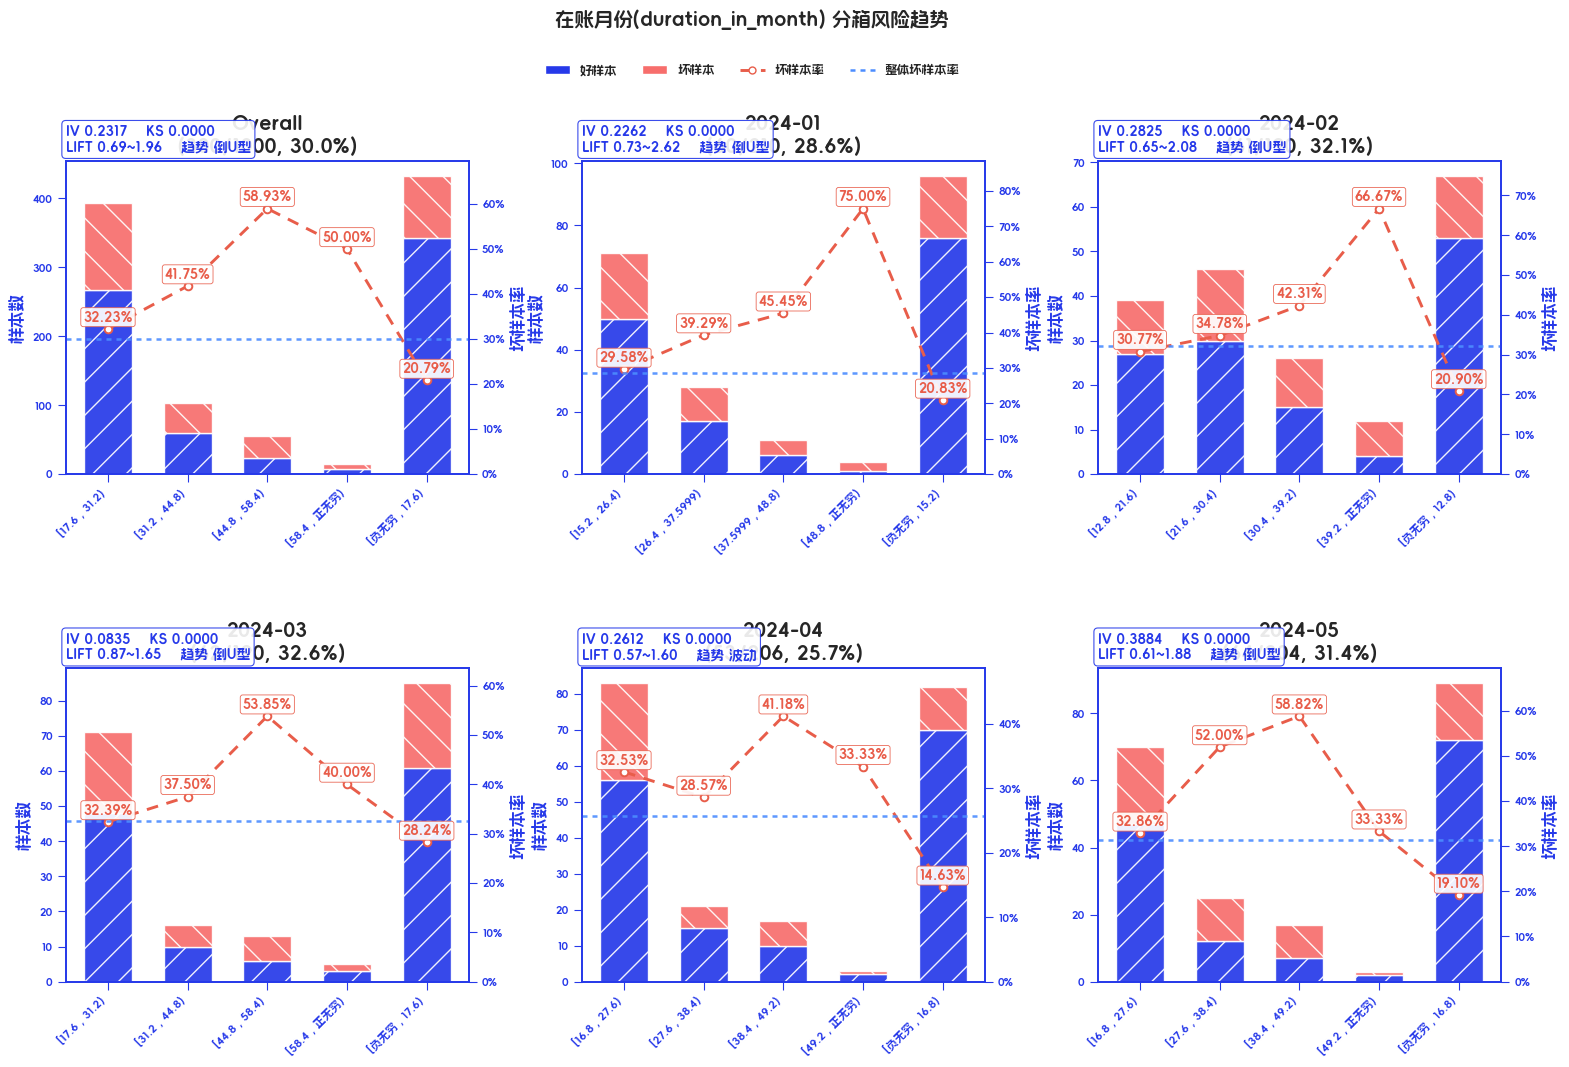

In [24]:
# 模拟时间维度数据
np.random.seed(42)
data_trend = data.copy()
# 创建模拟的时间周期（月份）
data_trend['period'] = np.random.choice(['2024-01', '2024-02', '2024-03', '2024-04', '2024-05'], size=len(data_trend))

# 按时间维度展示特征分箱趋势
fig = bin_trend_plot(
    data_trend,
    feature='duration_in_month',
    target=target,
    dimension_cols='period',
    date_freq='M',
    method='step',
    max_n_bins=5,
    sort_order='asc',
    title='在账月份(duration_in_month) 分箱风险趋势',
    # save='model_report/duration_in_month_trend.png'
)

### 批量特征分箱风险趋势图

`batch_bin_trend_plot` 用于批量绘制多个特征的风险趋势图，按 IV 或 KS 排序后自动生成并保存。

[1/3] Plotting duration_in_month...
[2/3] Plotting credit_amount...
[3/3] Plotting age_in_years...


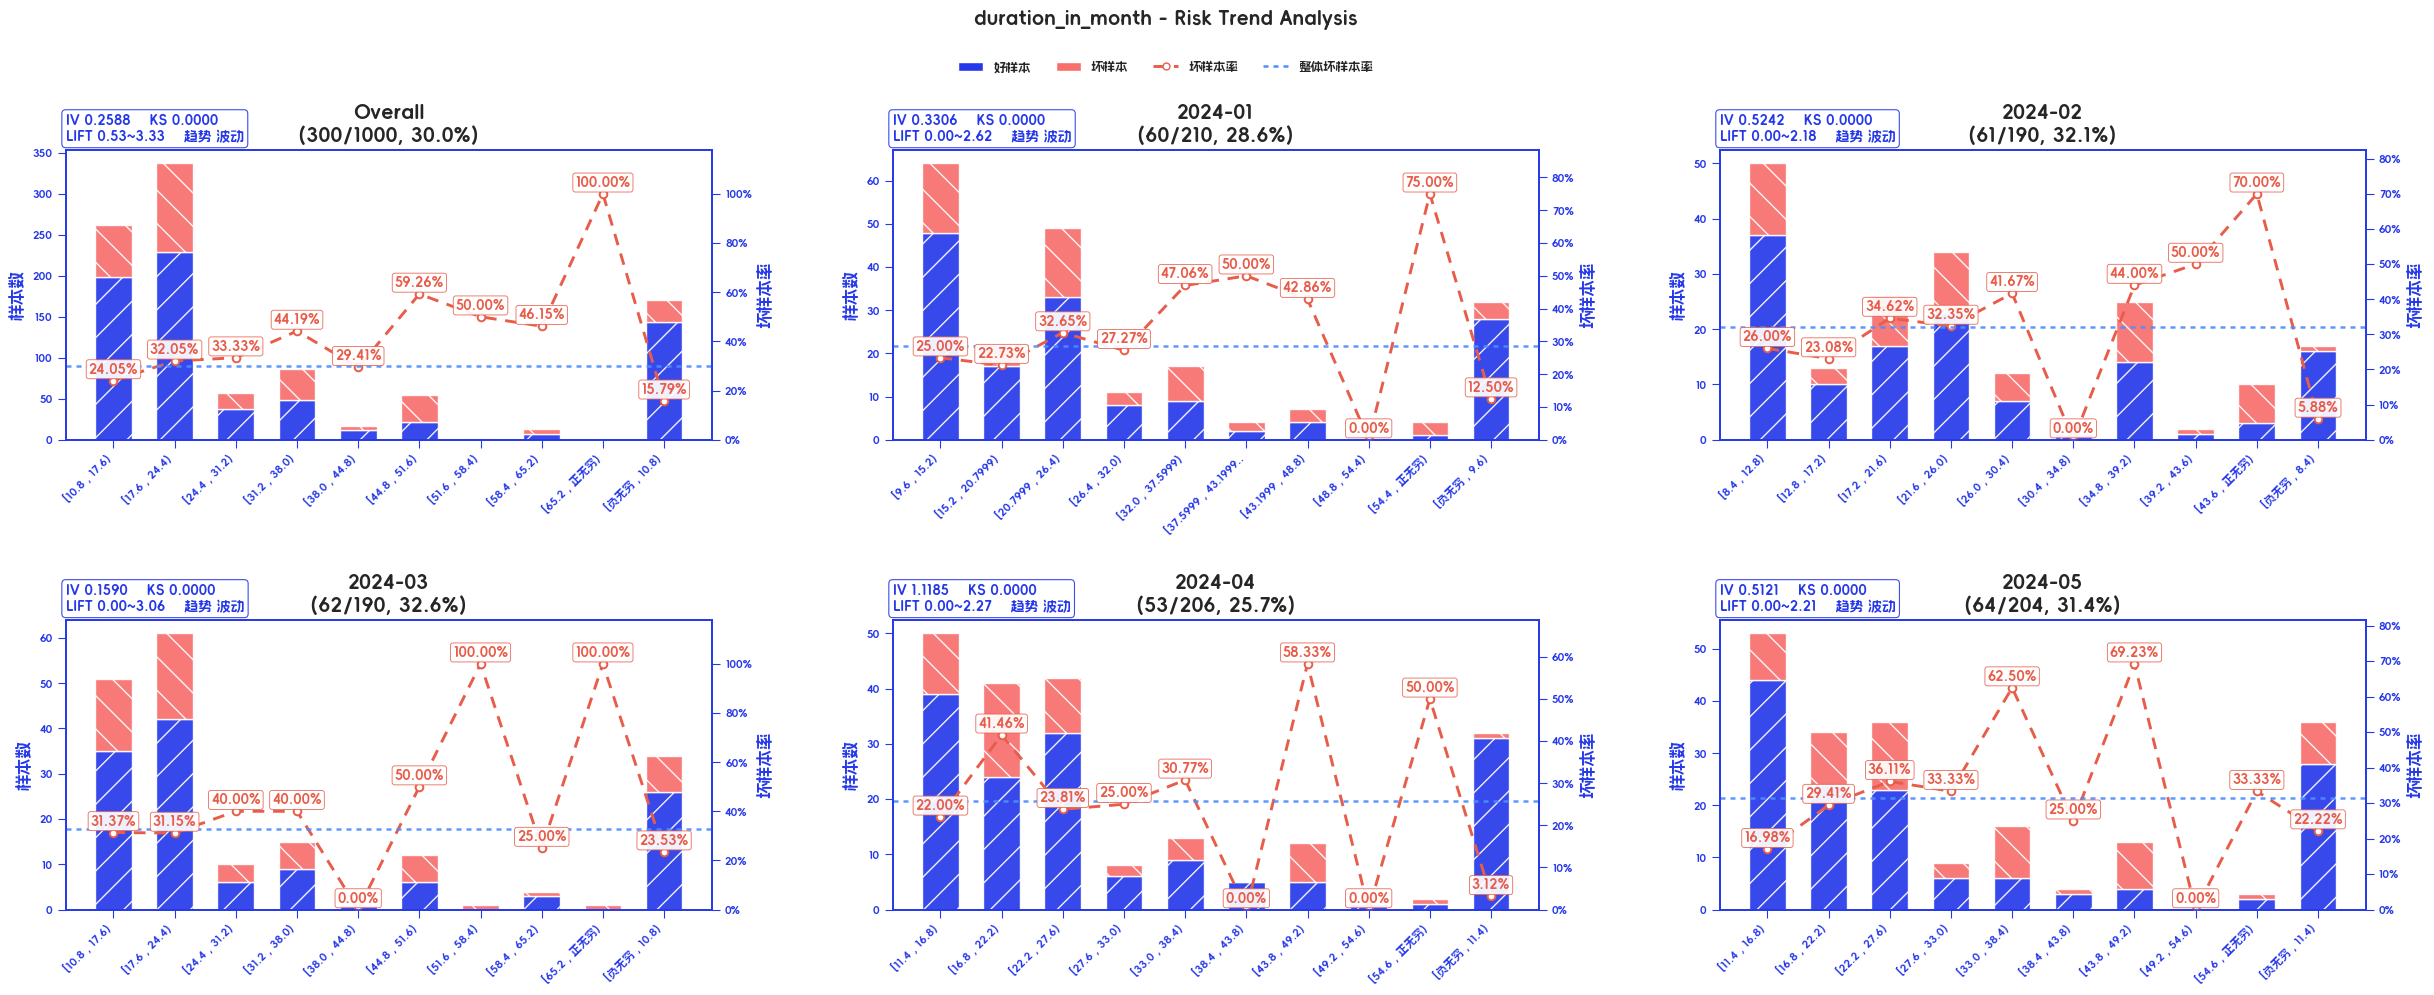

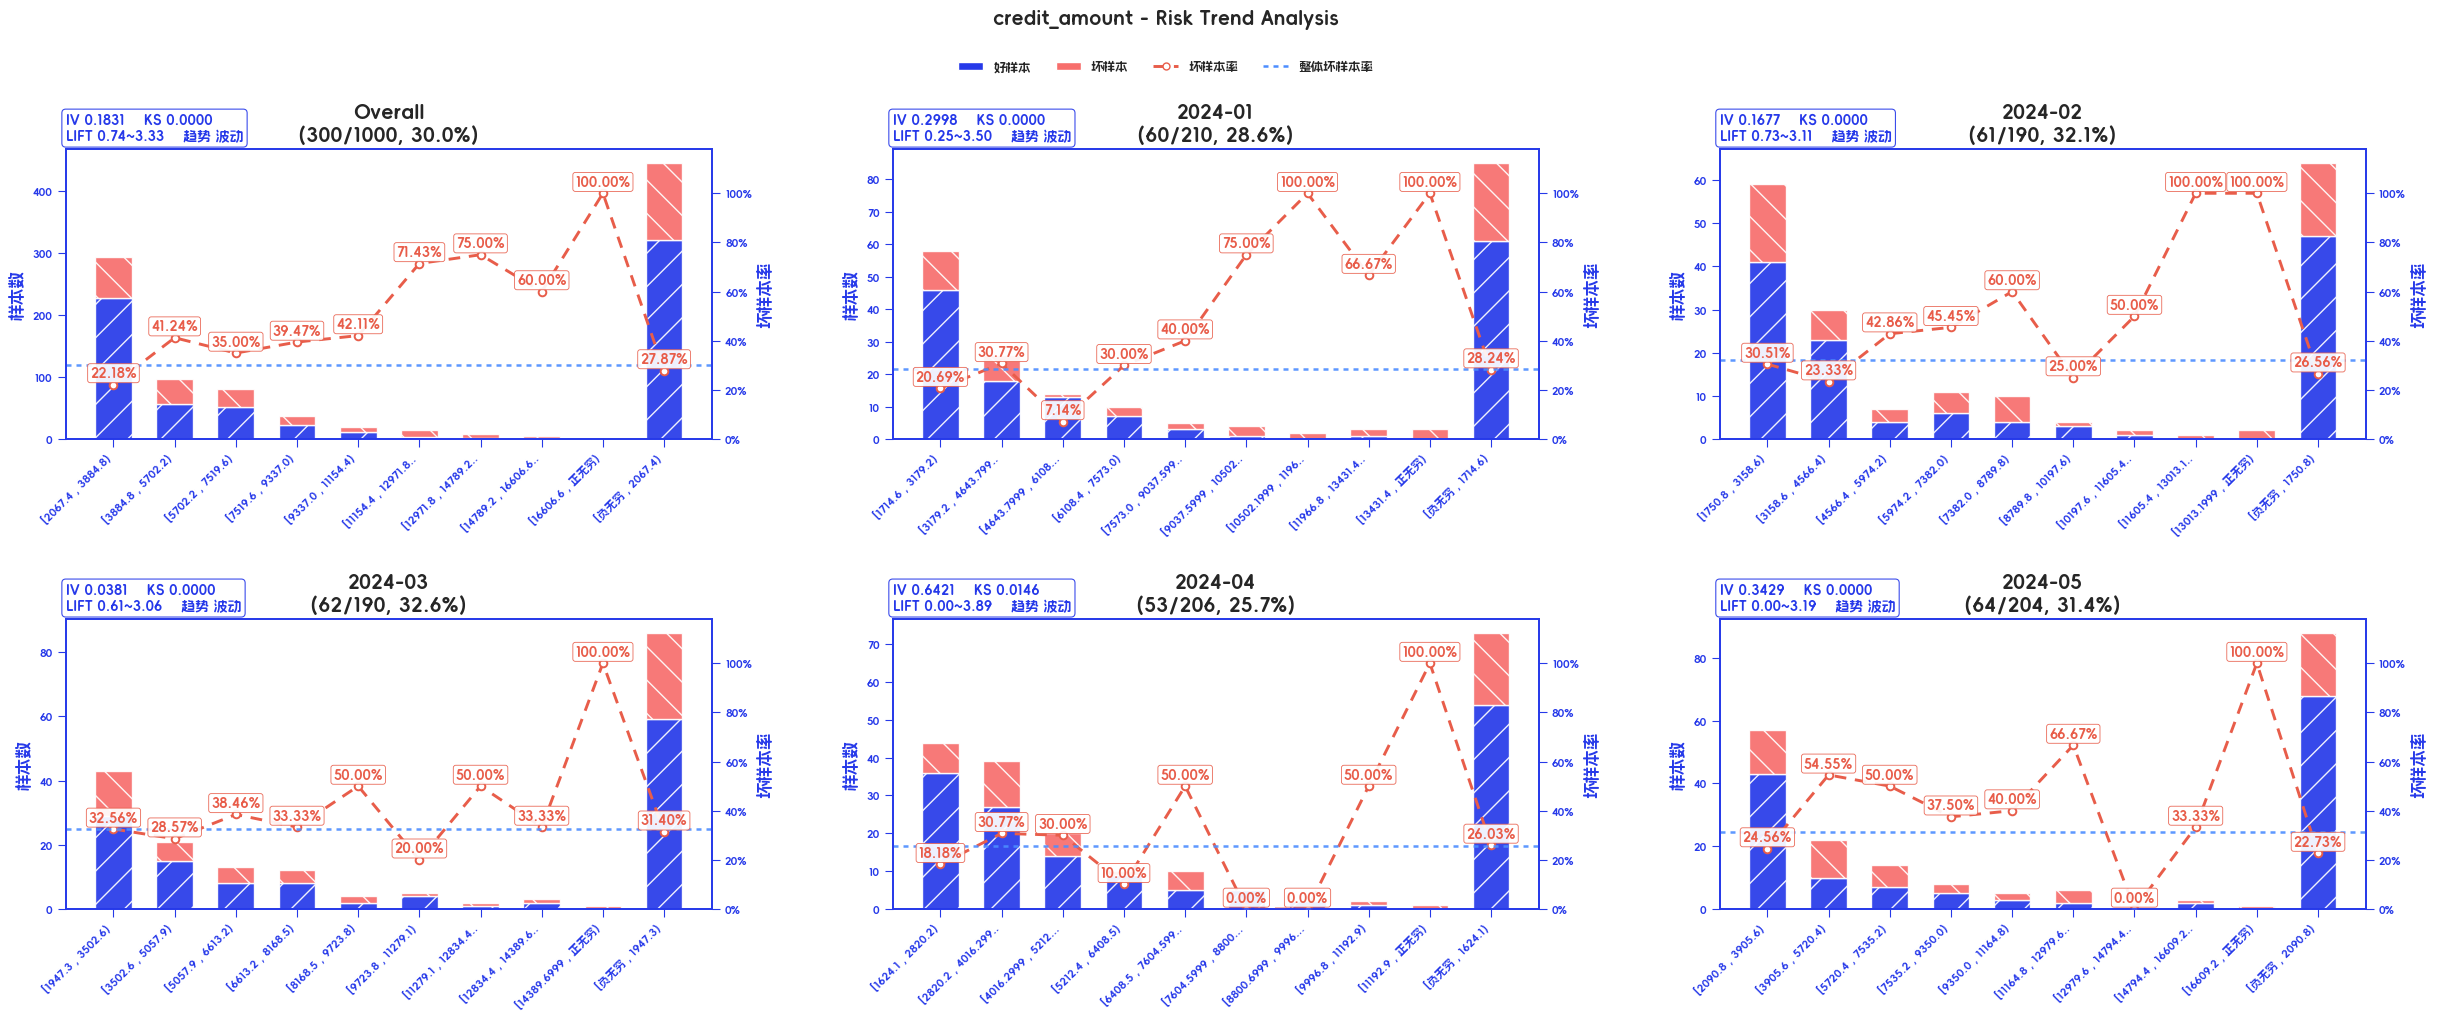

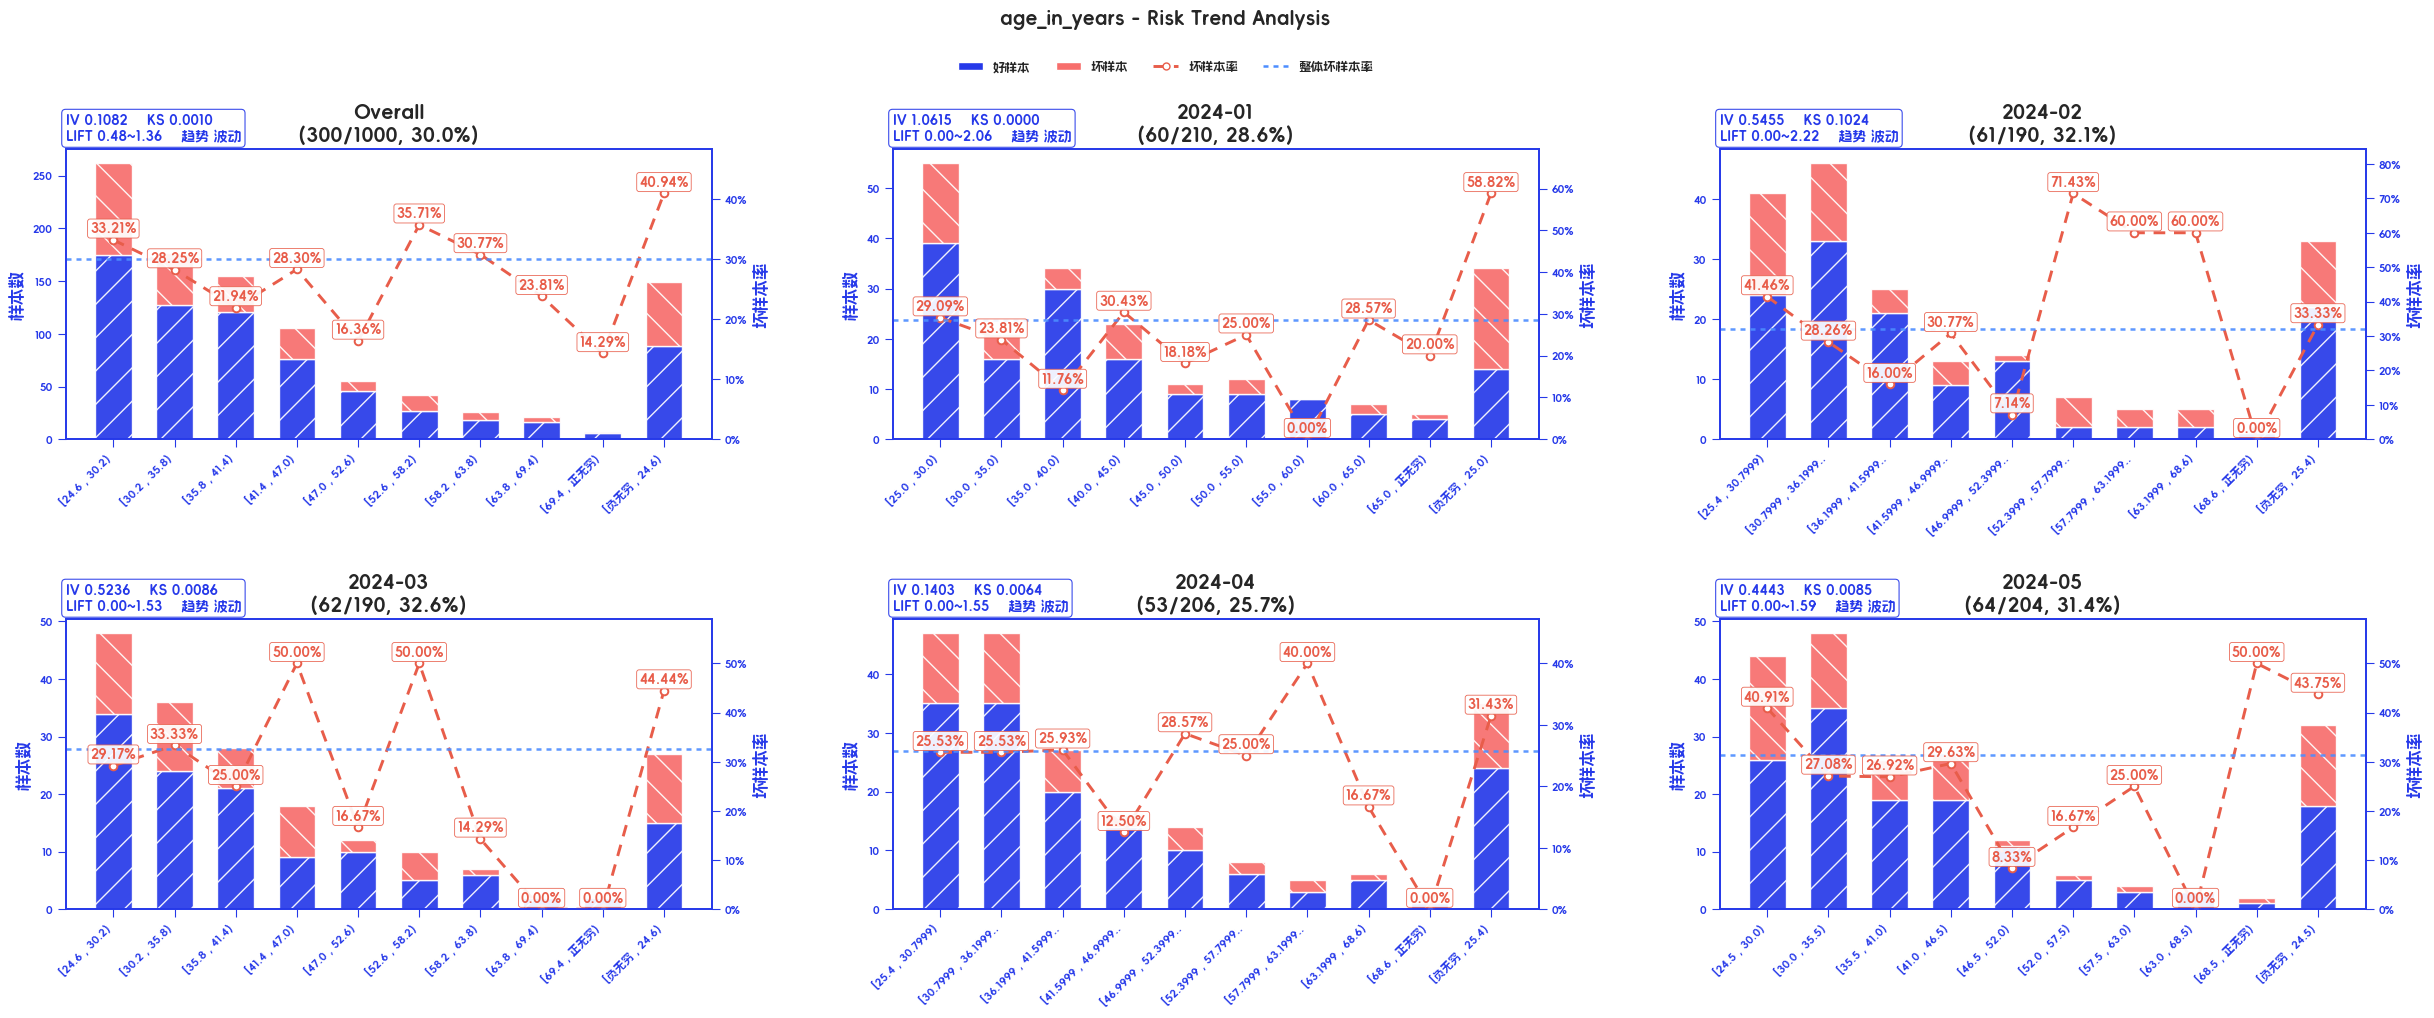

In [25]:
# 批量绘制多个特征的分箱风险趋势图
features_to_plot = ['duration_in_month', 'credit_amount', 'age_in_years']

results = batch_bin_trend_plot(
    data_trend,
    features=features_to_plot,
    target=target,
    dimension_cols='period',
    date_freq='M',
    sort_by='iv',
    max_features=3,
    save_dir='model_report',
    figsize=(25, 10),
)

### 多逾期天数分箱图

`bin_overdues_plot` 用于绘制多个逾期天数的分箱图，支持按不同 DPD 阈值展示坏样本率对比。支持两种输入方式：
1. 原始数据 + overdue + dpds：根据原始数据计算分箱并绘图
2. 分箱表（来自 feature_bin_stats）：直接解析多级表头分箱表并绘图

In [26]:
feature_bin_stats(
    data,
    feature='duration_in_month',
    overdue=['MOB1'],
    dpd=[0, 3],
    method='step',
    max_n_bins=5
)


分箱详情                                 MOB1 0+                                                                                                                       MOB1 3+                                                                                                                     
                指标名称 指标含义             分箱 样本总数   样本占比    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  分档WOE值  分档IV值  指标IV值  LIFT值    坏账改善   风险拒绝比 累积LIFT值  累积坏账改善  累积风险拒绝比 累积好样本数 累积坏样本数   分档KS值    好样本数  好样本占比 坏样本数  坏样本占比   坏样本率  分档WOE值  分档IV值  指标IV值  LIFT值    坏账改善   风险拒绝比 累积LIFT值  累积坏账改善 累积风险拒绝比 累积好样本数 累积坏样本数   分档KS值
0  duration_in_month        [负无穷 , 17.6)  433 0.4330     353 0.4380   80 0.4124 0.1848  0.0602 0.0015 0.0694 0.9524 -0.0364 -0.0840  1.0364 -0.0364  -0.0840    353     80 -0.0256     360 0.4358   73 0.4195 0.1686  0.0381 0.0006 0.0373 0.9689 -0.0237 -0.0548  1.0237 -0.0237 -0.0548    360     73 -0.0163
1  duration_in_month       [17.6 , 31.2)  394 0.3940     311 0.3859   83 0.4278 0.2107 -0.1033 0.0043 0.0694 1.0859  0.0558  0.1417  0.9237  0.0763   0.1937    664    163  0.0164     317 0.3838   77 0.4425 0.1954 -0.1424 0.0084 0.0373 1.1232  0.0801  0.2032  0.7973  0.2027  0.5145    677    150  0.0425
2  duration_in_month       [31.2 , 44.8)  103 0.1030      92 0.1141   11 0.0567 0.1068  0.6997 0.0402 0.0694 0.5505 -0.0516 -0.5011  1.4728 -0.4728  -4.5898    756    174 -0.0411      92 0.1114   11 0.0632 0.1068  0.5663 0.0273 0.0373 0.6138 -0.0443 -0.4306  1.0673 -0.0673 -0.6536    769    161 -0.0057
3  duration_in_month       [44.8 , 58.4)   56 0.0560      41 0.0509   15 0.0773 0.2679 -0.4187 0.0111 0.0694 1.3807  0.0226  0.4033  1.8409 -0.8409 -15.0168    797    189 -0.0146      46 0.0557   10 0.0575 0.1786 -0.0315 0.0001 0.0373 1.0263  0.0016  0.0278  1.2315 -0.2315 -4.1344    815    171 -0.0039
4  duration_in_month        [58.4 , 正无穷)   14 0.0140       9 0.0112    5 0.0258 0.3571 -0.8365 0.0122 0.0694 1.8409  0.0119  0.8529  0.0000  0.0000   0.0000    806    194  0.0000      11 0.0133    3 0.0172 0.2143 -0.2583 0.0010 0.0373 1.2315  0.0033  0.2348  0.0000  0.0000  0.0000    826    174  0.0000

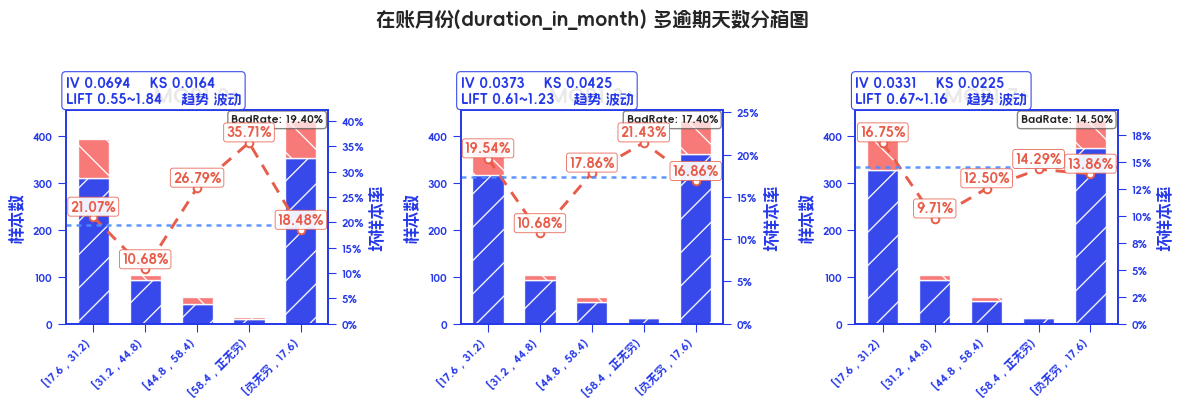

In [27]:
# 方式1：使用原始数据 + overdue + dpds 绘制多逾期天数分箱图
fig = bin_overdues_plot(
    data,
    feature='duration_in_month',
    overdue=['MOB1'],
    dpds=[0, 3, 7],
    method='step',
    max_n_bins=5,
    title='在账月份(duration_in_month) 多逾期天数分箱图',
    # save='model_report/duration_in_month_overdues.png'
)
plt.show()

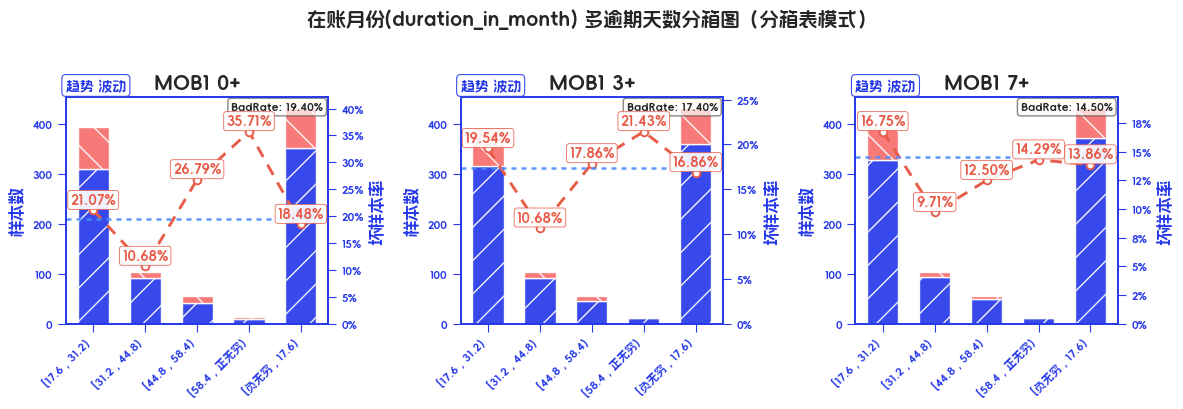

In [29]:
# 方式2：使用 feature_bin_stats 生成的分箱表（多级表头 DataFrame）直接绘图
# 先通过 feature_bin_stats 生成多逾期标签的分箱表
bin_table_multi = feature_bin_stats(
    data,
    feature='duration_in_month',
    overdue=['MOB1'],
    dpd=[0, 3, 7],
    method='step',
    max_n_bins=5
)

# 使用分箱表绘制多逾期天数分箱图
# 注意：分箱表模式需要使用 bin_table= 参数，而不是 data=
fig2 = bin_overdues_plot(
    bin_table=bin_table_multi,
    title='在账月份(duration_in_month) 多逾期天数分箱图（分箱表模式）',
    # save='model_report/duration_in_month_overdues_table.png'
)
plt.show()